In [1]:
# Standard imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_script_directory():
    try:
        # This will work if the script is run directly
        script_path = os.path.abspath(__file__)
    except NameError:
        # This will work in an interactive environment like Jupyter
        script_path = os.path.abspath('')
    
    return script_path

In [3]:
sys.path.append(r"C:\Users\varsh\OneDrive\Desktop\Virginia Tech 2\LS DYNA Simulations\Incremental driver\Trials (me)\pumat")

from lib.Load_Classes.Popular_Load_Class import PopularPath
from lib.Driver_Classes.Mod_Driver_Setup import DriverModelSetup
from lib.Driver_Classes.Mod_Driver_Model import DriverModel
from lib.general_functions.executing_runs import generate_batch_script, run_batch_script

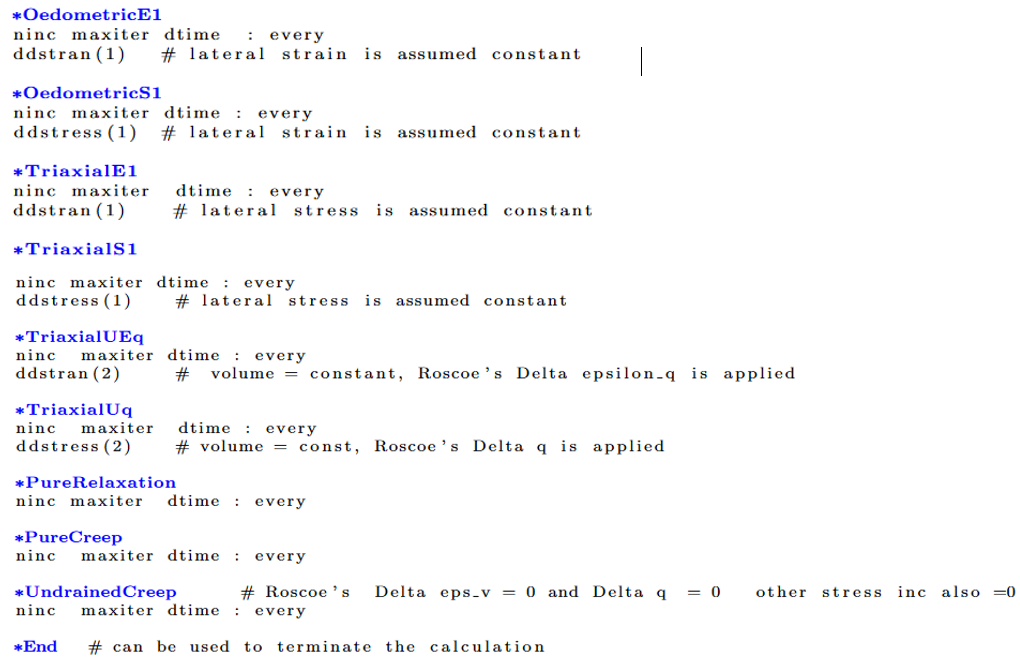

In [4]:
test_name = "TriaxialE1"
load_params = {
    "ninc": 10000,
    "maxiter": 5,
    "dtime"  : 10,
    "every"  : 1,
    "ddstran_1": -0.2,
}

load = PopularPath(test_name, load_params)

In [5]:
# This needs to be in the order that the parameters should be in
properties = {
    "xphics" : (24*np.pi)/180,
    "xNu" : 0.2,
    "xkappa" : 0.005,
    "xlambda" : 0.05,
    "xN" : 0.526,
    "m_Hrov" : 0.44

    
    # Input the other properties here

}

In [6]:
folder = get_script_directory()
# exe_name = r"CamClay_inc_Driver.exe"
exe_name = r"C:\Users\varsh\OneDrive\Desktop\Virginia Tech 2\LS DYNA Simulations\Incremental driver\Trials (me)\Modified_Cam_Clay_Potts\build\gfortran_E167FD2A985B468F\app\CamClay_inc_Driver.exe"

exe_path = os.path.join(folder, exe_name)

setup =DriverModelSetup(folder, "CamClay", "output.txt")

In [7]:
setup.store_loads(load)

In [8]:
print(setup)

Constitutive model name: CamClay
Folder path: c:\Users\varsh\OneDrive\Desktop\Virginia Tech 2\LS DYNA Simulations\Incremental driver\Trials (me)\pumat\4_MCC_Drained_test


In [9]:
setup.write_parameters_file(properties)
stress = [-100, -100, -100, 0, 0, 0]

# Make a dict of all the state parameters
# NOTE: There is no assumption that there are more state parameters than those entered here.
# If the state parameter should be zero at the start then it should entered here with a value of zero
state_params = {
    "pp": 2000,
    "v" : 0,
    "pwp" : 0,
    "EpsP1"     : 0,
    "EpsP2"     : 0,
    "EpsP3"     : 0,
    "EpsP4"     : 0,
    "EpsP5"     : 0,
    "EpsP6"     : 0
   
}

setup.write_initial_conditions_file(stress, state_params)
setup.write_loads()

In [10]:
generate_batch_script(folder, exe_path)
batch_file_path = os.path.join(folder, "run_model.bat")
run_batch_script(batch_file_path)

Batch file 'c:\Users\varsh\OneDrive\Desktop\Virginia Tech 2\LS DYNA Simulations\Incremental driver\Trials (me)\pumat\4_MCC_Drained_test\run_model.bat' executed successfully.


## This is just loading data and plotting

In [11]:
model= DriverModel(folder, "MCC", exe_path, "output.txt")

In [12]:
print(model.results)

Output file name: output.txt
Results folder path: c:\Users\varsh\OneDrive\Desktop\Virginia Tech 2\LS DYNA Simulations\Incremental driver\Trials (me)\pumat\4_MCC_Drained_test



In [13]:
model.results.store_all()

In [14]:
model.results.strain_df["stran(1)"]

0        0.00000
1       -0.00002
2       -0.00004
3       -0.00006
4       -0.00008
          ...   
9996    -0.19992
9997    -0.19994
9998    -0.19996
9999    -0.19998
10000   -0.20000
Name: stran(1), Length: 10001, dtype: float64

In [15]:
model.results.strain_df["stran(6)"]

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
9996     0.0
9997     0.0
9998     0.0
9999     0.0
10000    0.0
Name: stran(6), Length: 10001, dtype: float64

In [16]:
model.results.stress_df["stress(1)"]

0       -100.000000
1        -99.406946
2        -98.817988
3        -98.233106
4        -97.652279
            ...    
9996      -1.507255
9997      -1.507182
9998      -1.507116
9999      -1.507049
10000     -1.506985
Name: stress(1), Length: 10001, dtype: float64

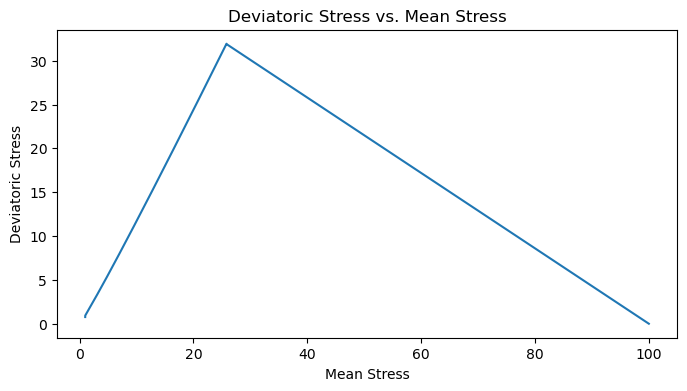

In [17]:
model.results.quick_plot_stress()

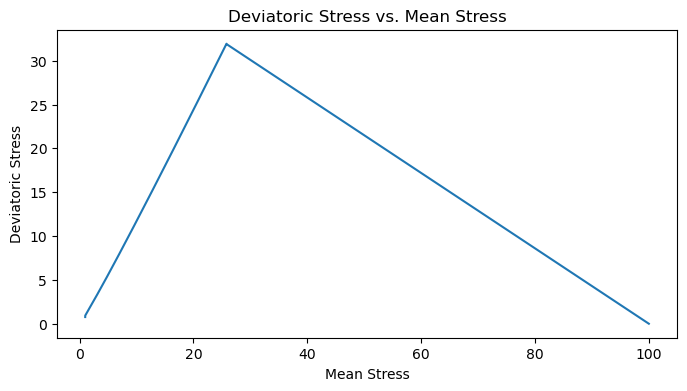

In [18]:
model.results.quick_plot_stress()

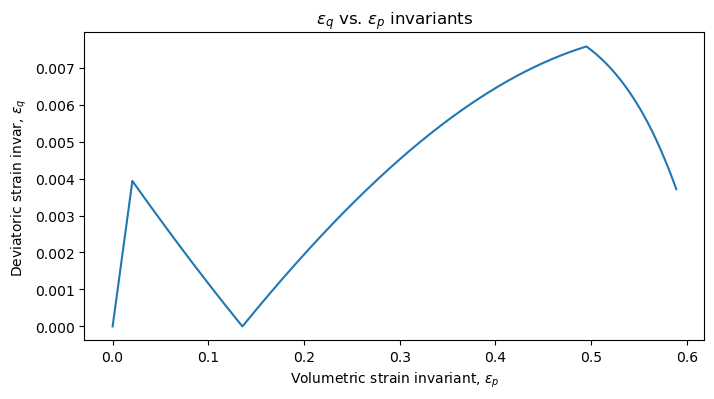

In [19]:
model.results.quick_plot_strain()

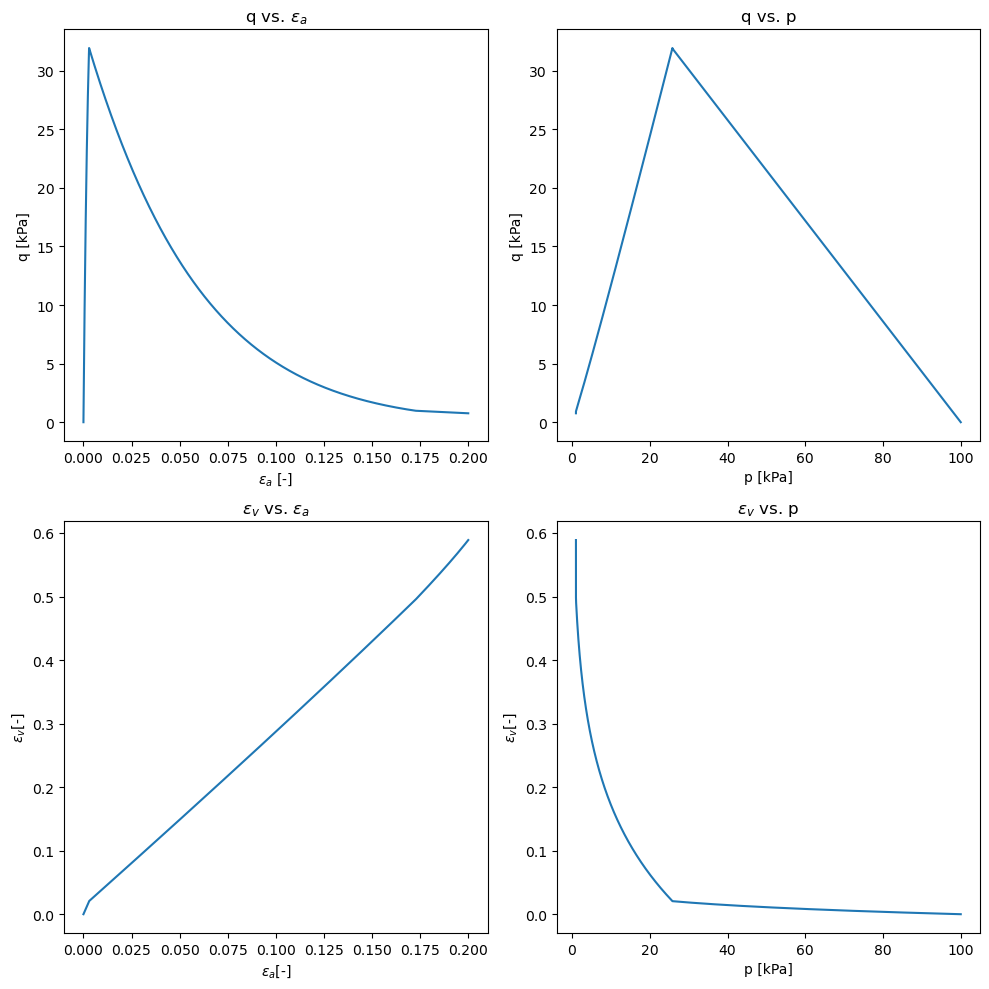

In [20]:
model.results.quick_quad_plot(compression_pos=True)

In [21]:
q = model.results.get_q_invariant()
p = model.results.get_mean_stress()

(-10.0, 160.0)

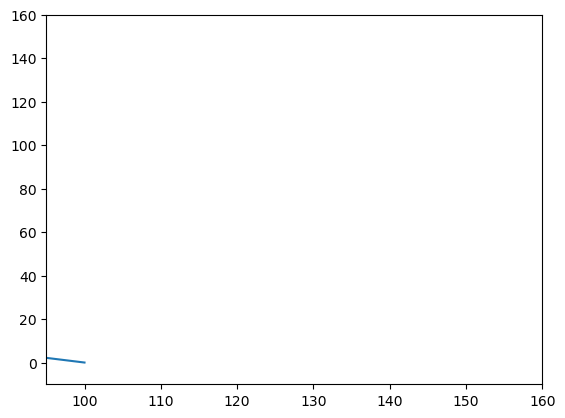

In [22]:
plt.plot(-1.0 * p, q)
plt.xlim([95, 160])
plt.ylim([-10, 160])